In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as plt

train = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML интенсив 12-18.08.2026/Lesson 2/train_contest.csv')
test = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ML интенсив 12-18.08.2026/Lesson 2/test_contest.csv')

In [ ]:
train.head(3)

,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,cat10,...,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14,target
0,B,A,A,B,A,B,A,A,A,A,...,0.516811,0.512119,0.80058,0.44352,0.63026,0.705501,0.692256,0.516660,0.678592,2730.63
1,A,B,A,A,A,A,A,B,B,A,...,0.499177,0.443760,0.43518,0.66201,0.57716,0.644013,0.630853,0.354344,0.236668,1430.29
2,B,B,A,A,A,B,A,A,B,A,...,0.818056,0.575090,0.66201,0.64681,0.68039,0.863052,0.879347,0.820538,0.714493,2422.54


In [ ]:
test.head(3)

,index,cat1,cat2,cat3,cat4,cat5,cat6,cat7,cat8,cat9,...,cont5,cont6,cont7,cont8,cont9,cont10,cont11,cont12,cont13,cont14
0,0,A,A,A,A,A,B,A,A,A,...,0.281143,0.185542,0.453037,0.42930,0.15370,0.25183,0.317685,0.321570,0.135482,0.800951
1,1,B,B,A,B,A,A,A,A,B,...,0.758711,0.178538,0.267980,0.24564,0.22089,0.21230,0.204687,0.202213,0.246011,0.290583
2,2,A,A,A,A,A,B,A,A,A,...,0.568839,0.517986,0.497685,0.50658,0.57506,0.56627,0.441763,0.443374,0.342239,0.244028


In [ ]:
y_train = train['target']
X_train = train.drop(columns='target')

num_cols = X_train.select_dtypes(include = 'number').columns
cat_cols = X_train.select_dtypes(exclude = 'number').columns

print('Числовых:', len(num_cols))
print('Категориальных:', len(cat_cols))

Числовых: 14
Категориальных: 116


**Анализ категориальных признаков:**
посмотрим как каждый из них влияется на таргет

In [ ]:
info = pd.DataFrame({
    'dtype': X_train.dtypes,
    'missing': X_train.isna().sum(),
    'missing_%': X_train.isna().mean() * 100,
    'n_unique': X_train.nunique()
})
info.sort_values('missing_%', ascending = False)

,dtype,missing,missing_%,n_unique
cat1,object,0,0.0,2
cat2,object,0,0.0,2
cat3,object,0,0.0,2
cat4,object,0,0.0,2
cat5,object,0,0.0,2
...,...,...,...,...
cont10,float64,0,0.0,171
cont11,float64,0,0.0,314
cont12,float64,0,0.0,316
cont13,float64,0,0.0,350


In [ ]:
import numpy as np
import pandas as pd

def eta_squared(df, feature, target):
    data = df[[feature, target]].dropna()

    grand_mean = data[target].mean()

    groups = data.groupby(feature)[target]

    n = groups.count()
    means = groups.mean()

    between = ((means - grand_mean) ** 2 * n).sum()
    total = ((data[target] - grand_mean) ** 2).sum()

    return between / total


cat_results = []

for col in cat_cols:
    score = eta_squared(train, col, 'target')

    cat_results.append({
        'feature': col,
        'eta_squared': score,
        'n_unique': X_train[col].nunique(),
        'missing_%': X_train[col].isna().mean() * 100
    })

cat_results = (
    pd.DataFrame(cat_results)
    .sort_values('eta_squared', ascending=False)
)

cat_results.head(10)

,feature,eta_squared,n_unique,missing_%
79,cat80,0.235546,4,0.0
78,cat79,0.213180,4,0.0
86,cat87,0.132041,4,0.0
100,cat101,0.130799,17,0.0
56,cat57,0.100144,2,0.0
99,cat100,0.097532,15,0.0
11,cat12,0.097042,2,0.0
80,cat81,0.080355,4,0.0
9,cat10,0.079952,2,0.0
88,cat89,0.079656,7,0.0


In [ ]:
cat_results.tail(10)

,feature,eta_squared,n_unique,missing_%
59,cat60,0.000213,2,0.0
55,cat56,0.000152,2,0.0
53,cat54,0.000075,2,0.0
87,cat88,0.000066,4,0.0
26,cat27,0.000037,2,0.0
20,cat21,0.000035,2,0.0
21,cat22,0.000032,2,0.0
14,cat15,0.000011,2,0.0
62,cat63,0.000006,2,0.0
69,cat70,0.000002,2,0.0


**Анализ числовых признаков:**
посмотрим как каждый из них влияется на таргет, посчитав корреляцию

In [ ]:
num_results = []

for col in num_cols:
    corr = X_train[col].corr(y_train)

    num_results.append({
        'feature': col,
        'correlation': corr,
        'abs_correlation': abs(corr),
        'missing_%': X_train[col].isna().mean() * 100,
        'n_unique': X_train[col].nunique()
    })

num_results = (
    pd.DataFrame(num_results)
    .sort_values('abs_correlation', ascending=False)
)

num_results

,feature,correlation,abs_correlation,missing_%,n_unique
1,cont2,0.140344,0.140344,0.0,33
6,cont7,0.117497,0.117497,0.0,5245
2,cont3,0.110438,0.110438,0.0,76
10,cont11,0.099388,0.099388,0.0,314
11,cont12,0.098756,0.098756,0.0,316
5,cont6,0.041672,0.041672,0.0,2478
3,cont4,-0.036116,0.036116,0.0,112
7,cont8,0.031055,0.031055,0.0,197
9,cont10,0.020120,0.020120,0.0,171
13,cont14,0.018918,0.018918,0.0,16488


In [ ]:
num_results.tail(10)

,feature,correlation,abs_correlation,missing_%,n_unique
11,cont12,0.098756,0.098756,0.0,316
5,cont6,0.041672,0.041672,0.0,2478
3,cont4,-0.036116,0.036116,0.0,112
7,cont8,0.031055,0.031055,0.0,197
9,cont10,0.020120,0.020120,0.0,171
13,cont14,0.018918,0.018918,0.0,16488
8,cont9,0.015774,0.015774,0.0,340
4,cont5,-0.010319,0.010319,0.0,138
0,cont1,-0.009251,0.009251,0.0,635
12,cont13,-0.002094,0.002094,0.0,350


**Посмотрим на взаимную корреляцию числовых признаков:**
найдем автоматически пары признаков, которые сильно коррелируют между собой и по сути рассказывают нам одно и то же

In [ ]:
corr_matrix = X_train[num_cols].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = (
    upper
    .stack()
    .sort_values(ascending=False)
)

high_corr.head(20)

cont11  cont12    0.994388
cont1   cont9     0.930066
cont6   cont10    0.883466
        cont13    0.814368
cont1   cont10    0.808818
cont6   cont9     0.797544
cont9   cont10    0.786115
cont6   cont12    0.785181
        cont11    0.773606
cont1   cont6     0.757484
cont7   cont11    0.747064
        cont12    0.742652
cont10  cont12    0.713967
        cont13    0.706329
        cont11    0.702773
cont6   cont7     0.658775
cont9   cont13    0.641727
        cont12    0.625586
cont1   cont12    0.613355
cont9   cont11    0.606675
dtype: float64

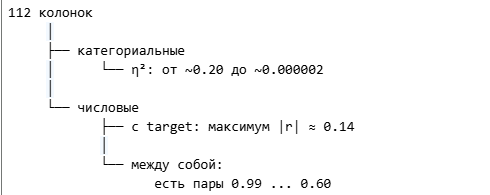

In [ ]:
X_train['cont11'].describe()
X_train['cont12'].describe()
X_train[['cont11', 'cont12']].head(10)

,cont11,cont12
0,0.705501,0.692256
1,0.644013,0.630853
2,0.863052,0.879347
3,0.644013,0.630853
4,0.415029,0.406090
5,0.689039,0.675759
6,0.711942,0.698722
7,0.207238,0.204687
8,0.341813,0.335036
9,0.625936,0.612906


In [ ]:
num_results[
    num_results['feature'].isin([
        'cont1',
        'cont6',
        'cont7',
        'cont9',
        'cont10',
        'cont11',
        'cont12',
        'cont13'
    ])
]

,feature,correlation,abs_correlation,missing_%,n_unique
6,cont7,0.117497,0.117497,0.0,5245
10,cont11,0.099388,0.099388,0.0,314
11,cont12,0.098756,0.098756,0.0,316
5,cont6,0.041672,0.041672,0.0,2478
9,cont10,0.020120,0.020120,0.0,171
8,cont9,0.015774,0.015774,0.0,340
0,cont1,-0.009251,0.009251,0.0,635
12,cont13,-0.002094,0.002094,0.0,350


In [ ]:
print(
    num_results[
        num_results['feature'].isin([
            'cont1', 'cont6', 'cont7', 'cont9',
            'cont10', 'cont11', 'cont12', 'cont13'
        ])
    ][['feature', 'correlation']].to_string(index=False)
)

feature  correlation
  cont7     0.117497
 cont11     0.099388
 cont12     0.098756
  cont6     0.041672
 cont10     0.020120
  cont9     0.015774
  cont1    -0.009251
 cont13    -0.002094


Убедимся, что у нас нет пропущенных значений в тренировочных данных

In [ ]:
X_train.isna().sum().sum()

np.int64(0)

In [ ]:
y_train.isna().sum()

np.int64(0)

Проверим Константные / почти константные признаки

In [ ]:
X_train.nunique().sort_values()

,0
cat1,2
cat2,2
cat3,2
cat4,2
cat5,2
...,...
cont13,350
cont1,635
cont6,2478
cont7,5245


уникального значения нет → константных признаков нет ✅
проверии, какие именно признаки имеют КУЧУ уникальных значений.

In [ ]:
X_train.nunique().sort_values(ascending=False).head(10)

,0
cont14,16488
cont7,5245
cont6,2478
cont1,635
cont13,350
cont9,340
cont12,316
cont11,314
cat116,307
cont8,197


проверим все категориальные признаки по количеству категорий:

In [ ]:
X_train[cat_cols].nunique().sort_values(ascending=False).head(15)

,0
cat116,307
cat110,125
cat109,81
cat113,59
cat112,51
cat115,23
cat107,20
cat105,19
cat114,18
cat101,17


к модели
1. Кодируем категориальные признаки
2. Объединяем числовые и категориальные
3. Обучаем Linear Regression

In [ ]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore')

X_train_cat = encoder.fit_transform(X_train[cat_cols])

In [ ]:
from scipy.sparse import hstack

X_train_final = hstack([
    X_train[num_cols],
    X_train_cat
])

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train_final, y_train)

LinearRegression()

Теперь подготовим test

In [ ]:
X_test_cat = encoder.transform(test[cat_cols])

X_test_final = hstack([
    test[num_cols],
    X_test_cat
])

И получаем предсказания:

In [ ]:
y_pred = model.predict(X_test_final)
y_pred

array([1944.65997044, 1855.88419445, 2177.26625865, ..., 2506.89247359,
       1565.43987088, 1073.09994471])

Делаем дата фрейм submission на выгрузку и сохраняем файл на компьютер

In [ ]:
submission = pd.DataFrame({
    'index': test['index'],
    'target': y_pred
})
submission.to_csv('submission.csv', index=False)

In [ ]:
submission

,index,target
0,0,1944.659970
1,1,1855.884194
2,2,2177.266259
3,3,2427.298734
4,4,5284.908417
...,...,...
51764,51764,2828.368053
51765,51765,1773.885069
51766,51766,2506.892474
51767,51767,1565.439871


In [ ]:
from google.colab import files

files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>